# Comparação LSTM vs BiLSTM (RUL FD001)

Notebook de orquestração: toda a lógica de dados, features e modelos está em `src/data.py`, `src/features.py` e `src/models.py`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "data.py").is_file():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import (
    CYCLE_COLUMN,
    DEFAULT_RUL_LIMIT,
    ID_COLUMN,
    assign_fd001_column_names,
    compute_test_rul,
    compute_train_rul,
    drop_missing_rows,
    drop_unused_sensor_columns,
    load_fd001_raw,
)
from src.features import create_fd001_windowed_features
from src.models import (
    compare_models_wilcoxon,
    plot_rul_prediction_diagnostics,
    plot_training_history,
    predict_rul,
    run_repeated_train_eval,
    search_hyperparameters,
    split_windowed_data,
    summarize_experiment_results,
)

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
TUNER_DIR = PROJECT_ROOT / "data" / "processed" / "keras_tuner"
CHECKPOINT_LSTM = PROJECT_ROOT / "data" / "processed" / "lstm_model.h5"
CHECKPOINT_BILSTM = PROJECT_ROOT / "data" / "processed" / "bi_model.h5"
TUNER_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "data" / "processed").mkdir(parents=True, exist_ok=True)

RUL_LIMIT = DEFAULT_RUL_LIMIT
WINDOW_SIZE = 30
WINDOW_STEP = 1
N_ITER = 10

## Carga e exploração inicial

In [2]:
raw = load_fd001_raw(DATA_RAW_DIR)
train_df, test_df = drop_missing_rows(raw.train, raw.test)
train_df, test_df, rul_df = assign_fd001_column_names(train_df, test_df, raw.rul)

print(train_df.head())

   ID  Nº Ciclos  Altitude [ft]    Mach    TRA  T2 [°R]  T24 [°R]  T30 [°R]  \
0   1          1        -0.0007 -0.0004  100.0   518.67    641.82   1589.70   
1   1          2         0.0019 -0.0003  100.0   518.67    642.15   1591.82   
2   1          3        -0.0043  0.0003  100.0   518.67    642.35   1587.99   
3   1          4         0.0007  0.0000  100.0   518.67    642.35   1582.79   
4   1          5        -0.0019 -0.0002  100.0   518.67    642.37   1582.85   

   T50[°R]  P2 [psia]  ...  phi [pps/psi]  NRf [rpm]  NRc [rpm]  BPR [-]  \
0  1400.60      14.62  ...         521.66    2388.02    8138.62   8.4195   
1  1403.14      14.62  ...         522.28    2388.07    8131.49   8.4318   
2  1404.20      14.62  ...         522.42    2388.03    8133.23   8.4178   
3  1401.87      14.62  ...         522.86    2388.08    8133.83   8.3682   
4  1406.22      14.62  ...         522.19    2388.04    8133.80   8.4294   

   farB [-]  htBleed [-]  Nf_dmd [rpm]  PCNfR_dmd [rpm]  W31 [lbm/s]

C:\Users\davim\AppData\Local\Temp\ipykernel_9448\1053843867.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


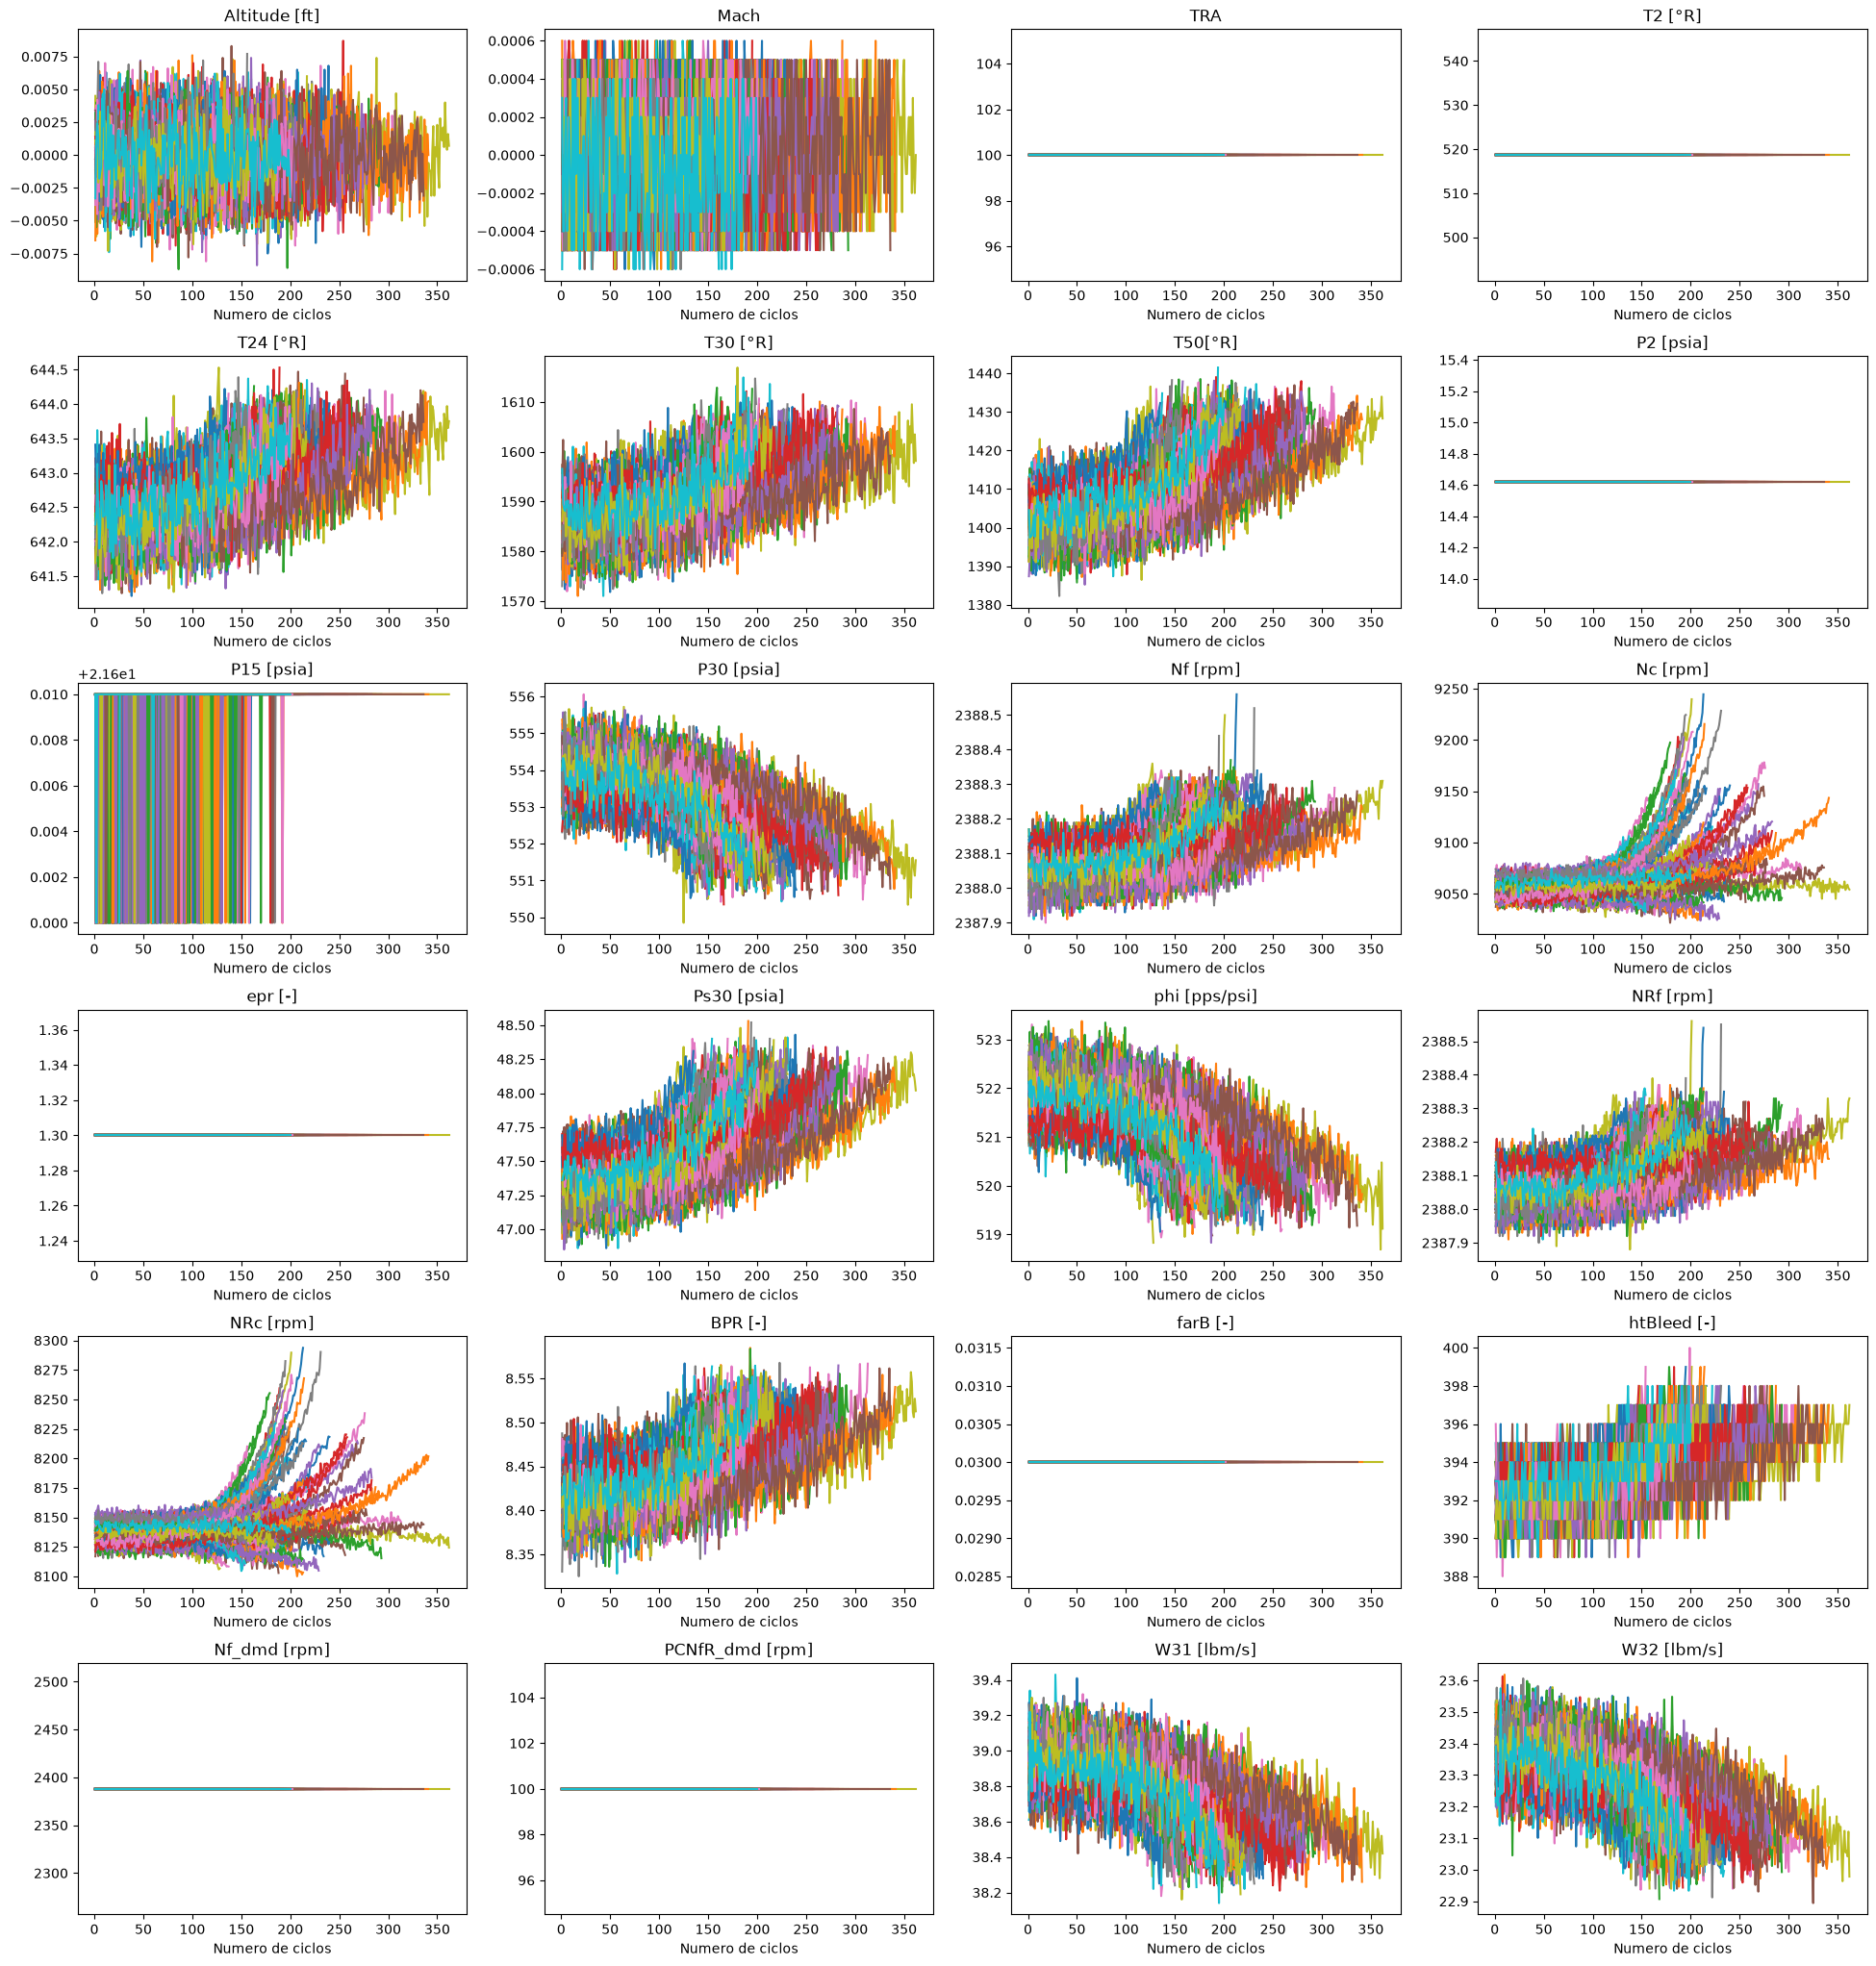

In [3]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(24, 20))
axes = axes.ravel()
for i, item in enumerate(train_df.columns[2:]):
    train_df.groupby(ID_COLUMN).plot(
        kind="line", x=CYCLE_COLUMN, y=item, ax=axes[i]
    )
    axes[i].set_title(f"{item}")
    axes[i].get_legend().remove()
    axes[i].set_xlabel("Número de ciclos")
    axes[i].set_ylabel("")

plt.subplots_adjust(top=0.99, bottom=0.01, hspace=0.3, wspace=0.2)
plt.show()

## Features, targets e janelas temporais

In [4]:
train_model, test_model = drop_unused_sensor_columns(train_df, test_df)
rul_train = compute_train_rul(train_model, limit=RUL_LIMIT)
rul_test = compute_test_rul(test_model, rul_df, limit=RUL_LIMIT)

windowed = create_fd001_windowed_features(
    train_model,
    test_model,
    rul_train,
    rul_test,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
)
x_train, y_train = windowed.x_train, windowed.y_train
x_test, y_test = windowed.x_test, windowed.y_test

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(17731, 30, 17) (17731,)
(10196, 30, 17) (10196,)


C:\Users\davim\AppData\Local\Temp\ipykernel_9448\1186367993.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


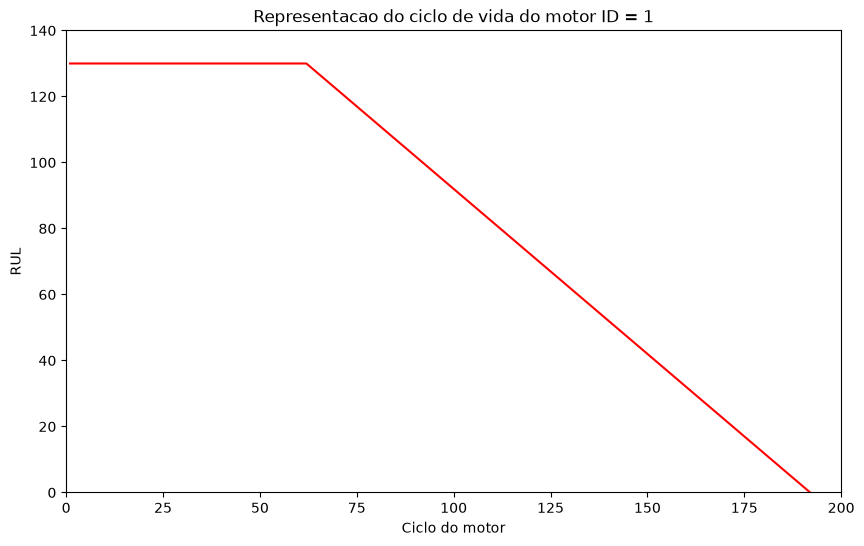

In [5]:
exemplo = train_df[train_df[ID_COLUMN] == 1]
n_cycles = len(exemplo[CYCLE_COLUMN])
rul_motor1 = compute_train_rul(exemplo, limit=RUL_LIMIT)

plt.figure(figsize=(10, 6))
plt.plot(exemplo[CYCLE_COLUMN].iloc[:n_cycles], rul_motor1[:n_cycles], c="red")
plt.title("Representação do ciclo de vida do motor ID = 1")
plt.ylim(0, 140)
plt.xlim(0, 200)
plt.xlabel("Ciclo do motor")
plt.ylabel("RUL")
plt.show()

## Partição treino/validação interna

In [6]:
x1, x2, y1, y2 = split_windowed_data(x_train, y_train, test_size=0.2, random_state=1)

## LSTM: busca de hiperparâmetros e avaliação repetida

In [7]:
best_model_lstm, best_params_lstm = search_hyperparameters(
    "lstm",
    x1,
    y1,
    x2,
    y2,
    tuner_directory=TUNER_DIR,
    project_name="hyper_lstm_hyperband",
    max_epochs=15,
    factor=3,
    hyperband_iterations=1,
    batch_size=200,
    patience=3,
    overwrite=False,
)

for key, value in best_params_lstm.items():
    print(f"{key:15s} -> {value}")

Trial 26 Complete [00h 04m 47s]
val_loss: 10.493353843688965

Best val_loss So Far: 10.493353843688965
Total elapsed time: 01h 17m 06s


lstm_0          -> 128
dropout_0       -> 0.4000000000000001
lstm_1          -> 64
dropout_1       -> 0.4000000000000001
dense_0         -> 32
dense_1         -> 1
learning_rate   -> 0.01


C:\Users\davim\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\saving\saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'rm_sprop', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(store)


C:\Users\davim\OneDrive\Documents\USP\capacitacao_hbr\tcc\src\models.py:383: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


C:\Users\davim\OneDrive\Documents\USP\capacitacao_hbr\tcc\src\models.py:422: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\davim\OneDrive\Documents\USP\capacitacao_hbr\tcc\src\models.py:430: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


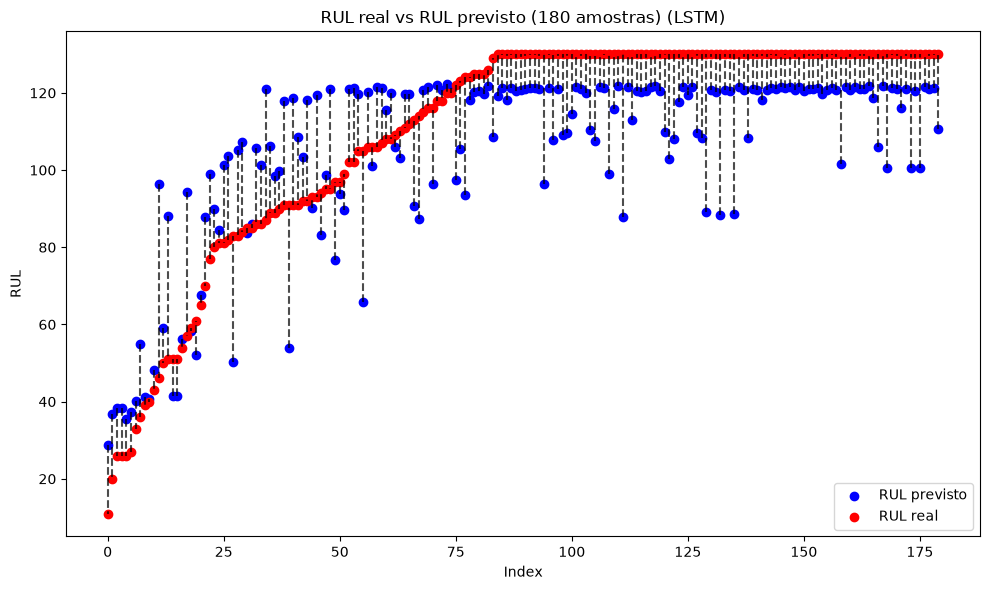

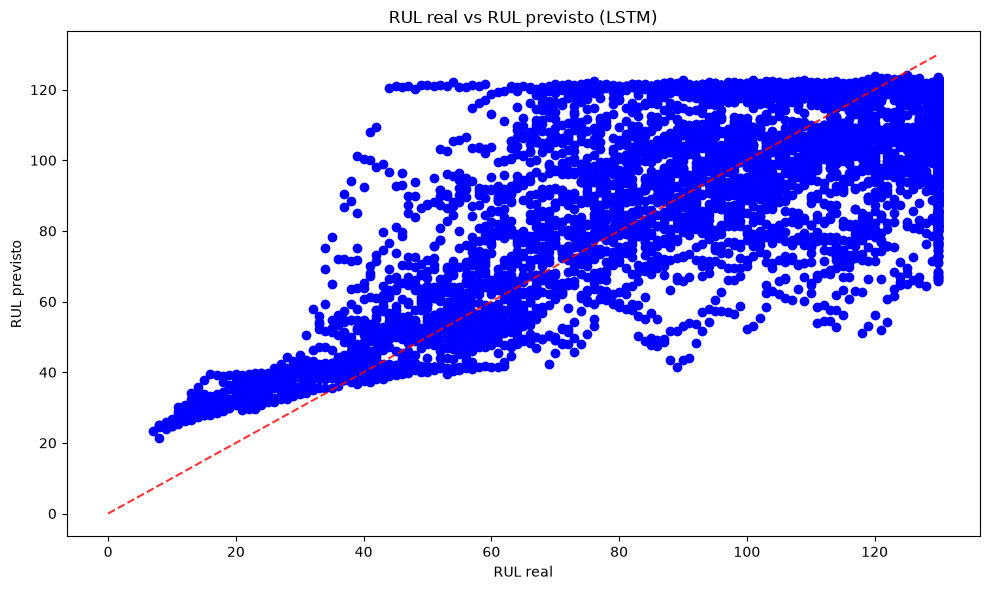

In [8]:
resultados_lstm, history_lstm = run_repeated_train_eval(
    best_model_lstm,
    x1,
    y1,
    x2,
    y2,
    x_test,
    y_test,
    CHECKPOINT_LSTM,
    n_iterations=N_ITER,
    capture_first_history=True,
)

if history_lstm is not None:
    plot_training_history(history_lstm, "LSTM")
    y_pred_lstm = predict_rul(best_model_lstm, x_test)
    plot_rul_prediction_diagnostics(
        y_test,
        y_pred_lstm,
        model_label="LSTM",
        rul_limit=RUL_LIMIT,
    )

## BiLSTM: busca de hiperparâmetros e avaliação repetida

In [9]:
best_model_bilstm, best_params_bilstm = search_hyperparameters(
    "bilstm",
    x1,
    y1,
    x2,
    y2,
    tuner_directory=TUNER_DIR,
    project_name="hyper_bi_hyperband",
    max_epochs=15,
    factor=3,
    hyperband_iterations=1,
    batch_size=200,
    patience=3,
    overwrite=False,
)

for key, value in best_params_bilstm.items():
    print(f"{key:15s} -> {value}")

Trial 30 Complete [00h 12m 36s]
val_loss: 11.667384147644043

Best val_loss So Far: 10.112059593200684
Total elapsed time: 02h 12m 38s


bi_0            -> 32
dropout_0       -> 0.2
bi_1            -> 64
dropout_1       -> 0.30000000000000004
dense_0         -> 1
learning_rate   -> 0.01


C:\Users\davim\OneDrive\Documents\USP\capacitacao_hbr\tcc\src\models.py:383: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


C:\Users\davim\OneDrive\Documents\USP\capacitacao_hbr\tcc\src\models.py:422: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
C:\Users\davim\OneDrive\Documents\USP\capacitacao_hbr\tcc\src\models.py:430: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


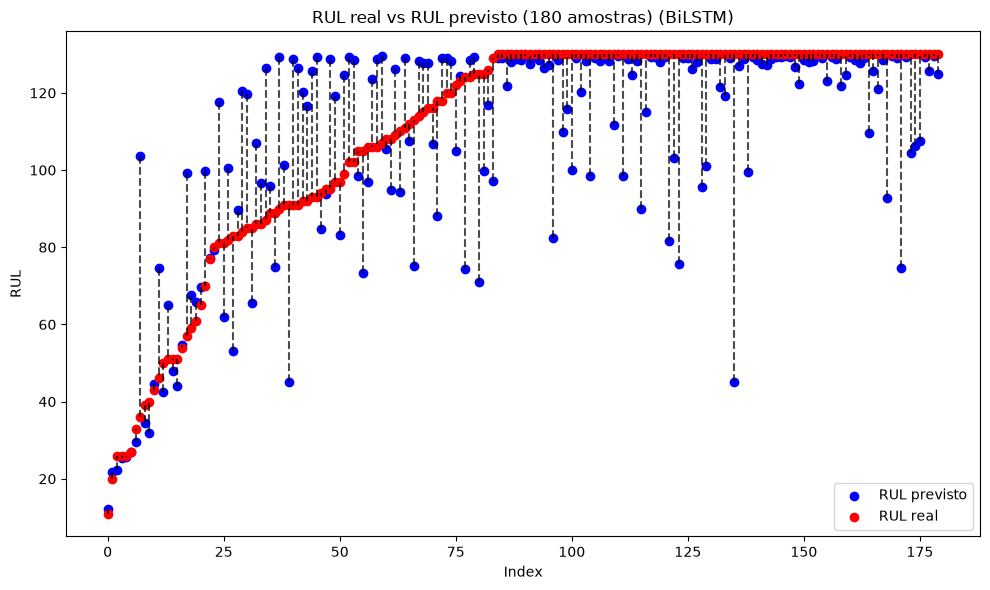

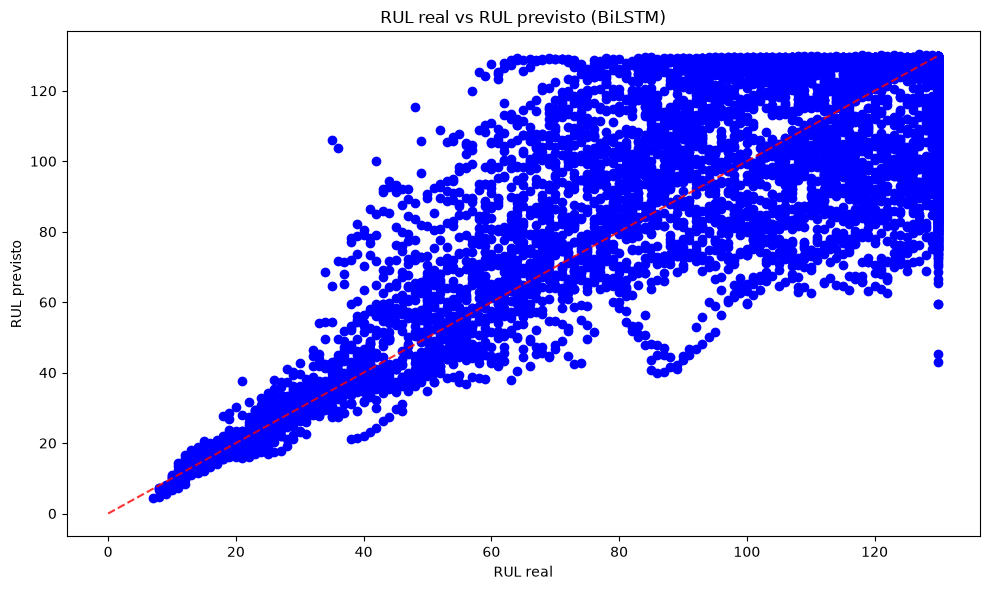

In [10]:
resultados_bilstm, history_bilstm = run_repeated_train_eval(
    best_model_bilstm,
    x1,
    y1,
    x2,
    y2,
    x_test,
    y_test,
    CHECKPOINT_BILSTM,
    n_iterations=N_ITER,
    capture_first_history=True,
)

if history_bilstm is not None:
    plot_training_history(history_bilstm, "BiLSTM")
    y_pred_bilstm = predict_rul(best_model_bilstm, x_test)
    plot_rul_prediction_diagnostics(
        y_test,
        y_pred_bilstm,
        model_label="BiLSTM",
        rul_limit=RUL_LIMIT,
    )

## Tratamento estatístico

In [11]:
print("Resultados LSTM".center(40, "-"))
print(f"{resultados_lstm.to_string(index=False)}\n")
print("Resultados BiLSTM".center(40, "-"))
print(f"{resultados_bilstm.to_string(index=False)}\n")

resumo_lstm = summarize_experiment_results(resultados_lstm)
resumo_bilstm = summarize_experiment_results(resultados_bilstm)

print("Resumo LSTM".center(40, "-"))
print(f"{resumo_lstm}\n")
print("Resumo BiLSTM".center(40, "-"))
print(f"{resumo_bilstm}\n")

wilcoxon_df = compare_models_wilcoxon(resultados_lstm, resultados_bilstm)
print("Teste de Wilcoxon".center(40, "-"))
for _, row in wilcoxon_df.iterrows():
    metrica = row["metrica"]
    valorp = row["p_value"]
    if row["significativo"]:
        conclusao = "A diferença é estatisticamente significativa"
    else:
        conclusao = "A diferença não é estatisticamente significativa"
    print(f"O p-value para {metrica} é {valorp}. {conclusao}")

------------Resultados LSTM-------------
 Iteração        MSE      RMSE       MAE       R2      tempo
        1 280.394745 16.744992 13.484202 0.716869 348.720955
        2 308.085667 17.552369 11.832414 0.688908 132.753638
        3 283.813778 16.846774 13.460546 0.713417 176.181046
        4 285.208542 16.888118 13.541134 0.712008 241.943541
        5 279.190929 16.709007 13.241987 0.718085 219.085895
        6 282.649123 16.812172 11.728294 0.714593 175.312179
        7 294.059325 17.148158 12.870405 0.703071 154.514633
        8 398.543785 19.963561 15.671140 0.597567 327.670734
        9 330.312855 18.174511 14.828987 0.666464 200.112109
       10 330.699081 18.185134 14.237286 0.666074 209.876790

-----------Resultados BiLSTM------------
 Iteração        MSE      RMSE       MAE       R2      tempo
        1 216.961234 14.729604 10.449021 0.780922 340.674343
        2 286.344055 16.921704 11.883842 0.710862 423.975097
        3 349.067344 18.683344 13.417734 0.647526 318.980492
  